***Import Libraries***

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
from scipy.spatial.distance import cosine
from scipy.optimize import linear_sum_assignment
import glob
import os
from shapely import wkt
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

***Data Preprocessing***

Combine geometric data with stats, and ideal plans files. Compute the centroid and save in a separate file.

In [ ]:
maps = pd.read_csv("/content/IL_2020_maps.csv")
print(maps.head())
print(maps.size)
maps.columns

         GEOID state        county     muni        county_muni  cd_2010  \
0  17001001001    IL  Adams County      NaN       Adams County     18.0   
1  17001002001    IL  Adams County      NaN       Adams County     18.0   
2  17001003001    IL  Adams County  10877.0  Adams County10877     18.0   
3  17001003002    IL  Adams County      NaN       Adams County     18.0   
4  17001004001    IL  Adams County      NaN       Adams County     18.0   

   cd_2020     vtd  pop  pop_hisp  ...  adv_18  arv_20  adv_20    nrv    ndv  \
0       15  001001  958        13  ...    93.0   372.0    94.5  291.9  102.7   
1       15  002001  836        14  ...    80.3   378.5    72.0  300.6   85.0   
2       15  003001  756         8  ...    59.7   346.5    62.0  274.4   70.0   
3       15  003002  898        12  ...    62.0   399.0    52.5  320.1   65.1   
4       15  004001  186         3  ...    20.3   114.5    20.5   97.6   21.1   

   area_land  area_water                 adj  pseudo_county  \
0   9

Index(['GEOID', 'state', 'county', 'muni', 'county_muni', 'cd_2010', 'cd_2020',
       'vtd', 'pop', 'pop_hisp', 'pop_white', 'pop_black', 'pop_aian',
       'pop_asian', 'pop_nhpi', 'pop_other', 'pop_two', 'vap', 'vap_hisp',
       'vap_white', 'vap_black', 'vap_aian', 'vap_asian', 'vap_nhpi',
       'vap_other', 'vap_two', 'pre_16_dem_cli', 'pre_16_rep_tru',
       'uss_16_dem_duc', 'uss_16_rep_kir', 'gov_18_dem_pri', 'gov_18_rep_rau',
       'atg_18_dem_rao', 'atg_18_rep_har', 'sos_18_dem_whi', 'sos_18_rep_hel',
       'pre_20_dem_bid', 'pre_20_rep_tru', 'uss_20_dem_dur', 'uss_20_rep_cur',
       'arv_16', 'adv_16', 'arv_18', 'adv_18', 'arv_20', 'adv_20', 'nrv',
       'ndv', 'area_land', 'area_water', 'adj', 'pseudo_county',
       'geometry_wkt'],
      dtype='object')

In [ ]:
#Path to 100 ideal plans zip file
path_to_zip_file = '/content/idealPlans.zip'
extract_to_folder = 'ideal_content'

with zipfile.ZipFile(path_to_zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_to_folder)


search_path = os.path.join(extract_to_folder, "**", "*.csv")
all_files = glob.glob(search_path, recursive=True)

li = []

for filename in all_files:
    # Read the CSV
    df = pd.read_csv(filename, index_col=None, header=0)

    # Extract the base filename (e.g., 'idealPlan_37.csv')
    base_name = os.path.basename(filename)

    # Remove extension (e.g., 'idealPlan_37')
    name_no_ext = os.path.splitext(base_name)[0]

    # Logic to get '37' from 'idealPlan_37'
    try:
        # Splits at underscore and takes the last part
        plan_value = name_no_ext.split('_')[-1]
    except IndexError:
        plan_value = 'Unknown'

    # Assign to new column
    df['Plan'] = plan_value

    li.append(df)

# Check if we actually found files before trying to merge
if len(li) > 0:
    merged_ideal = pd.concat(li, axis=0, ignore_index=True)
    merged_ideal.to_csv('merged_ideal_plans.csv', index=False)
    print(f"Success! Merged {len(li)} files into 'merged_all_plans.csv'")
    print(merged_ideal.head())
else:
    print("No CSV files were found in the zipped folder.")

Success! Merged 99 files into 'merged_all_plans.csv'
   district   comp_bc  comp_box_reock   comp_ch   comp_lw  comp_polsby  \
0         1  0.875969        0.562368  0.769385  0.617305     0.299859   
1         2  0.906988        0.554789  0.818742  0.969833     0.350161   
2         3  0.845942        0.500866  0.684747  0.858208     0.211677   
3         4  0.833522        0.504674  0.699208  0.893528     0.167667   
4         5  0.839522        0.511111  0.753386  0.987191     0.206486   

   comp_reock  comp_schwartz  comp_skew       area_m2        perim_m   Plan  
0    0.426102       0.547594   0.426135  2.936251e+08  110928.505860  31454  
1    0.497426       0.591744   0.504243  2.152452e+09  277931.359090  31454  
2    0.413842       0.460084   0.377256  6.525195e+08  196817.940867  31454  
3    0.340687       0.409471   0.341379  2.856579e+08  146320.275592  31454  
4    0.430238       0.454408   0.409828  1.778677e+08  104041.824163  31454  


In [ ]:
# Convert maps dataframe to GeoDataFrame for centroid computation
maps['geometry'] = maps['geometry_wkt'].apply(wkt.loads)
maps_gdf = gpd.GeoDataFrame(maps, geometry='geometry')

# Dissolve precincts to districts (assuming districts 1-17)
districts = maps_gdf.dissolve(
    by='cd_2020',
    aggfunc={
        'pop': 'sum',
        'area_land': 'sum',
        'area_water': 'sum'
    }
).reset_index()

# Calculate geographic features (centroids, area, and perimeter)
districts['centroid_x'] = districts.geometry.centroid.x
districts['centroid_y'] = districts.geometry.centroid.y
districts['geom_area'] = districts.geometry.area
districts['perimeter'] = districts.geometry.length

print(f"\nDistricts computed: {len(districts)} districts")


Districts computed: 17 districts


In [ ]:
stats = pd.read_csv('/content/ideal_stats.csv')
stats.head()
print(stats.columns)

Index(['draw', 'district', 'total_pop', 'chain', 'pop_overlap', 'total_vap',
       'plan_dev', 'comp_edge', 'comp_polsby', 'pop_hisp', 'pop_white',
       'pop_black', 'pop_aian', 'pop_asian', 'pop_nhpi', 'pop_other',
       'pop_two', 'vap_hisp', 'vap_white', 'vap_black', 'vap_aian',
       'vap_asian', 'vap_nhpi', 'vap_other', 'vap_two', 'pre_16_dem_cli',
       'pre_16_rep_tru', 'uss_16_dem_duc', 'uss_16_rep_kir', 'gov_18_dem_pri',
       'gov_18_rep_rau', 'atg_18_dem_rao', 'atg_18_rep_har', 'sos_18_dem_whi',
       'sos_18_rep_hel', 'pre_20_dem_bid', 'pre_20_rep_tru', 'uss_20_dem_dur',
       'uss_20_rep_cur', 'arv_16', 'adv_16', 'arv_18', 'adv_18', 'arv_20',
       'adv_20', 'county_splits', 'muni_splits', 'ndv', 'nrv', 'ndshare',
       'e_dvs', 'pr_dem', 'e_dem', 'pbias', 'egap'],
      dtype='object')


In [ ]:
#join stats + ideal set files because stats has draw, and ideal set has top 100 plan numbers

# Standardize the key columns to Strings to ensure they match
merged_ideal['Plan'] = merged_ideal['Plan'].astype(str)
stats['draw'] = stats['draw'].astype(str)

# Perform the Merge
# left_on='Plan': Use 'Plan' column from df_ideal
# right_on='Draw': Use 'Draw' column from df_stats
# how='left': Keep all rows from df_ideal (the "merged ideal" file)
ideal_stats = pd.merge(
    merged_ideal,
    stats,
    left_on='Plan',
    right_on='draw',
    how='left'
)

# Save the result
ideal_stats.to_csv('final_combined_data.csv', index=False)

print("Merge complete.")
print(ideal_stats.head())
ideal_stats.drop([ 'total_vap', 'plan_dev',
       'pop_hisp', 'pop_white', 'pop_black', 'pop_aian', 'pop_asian',
       'pop_nhpi', 'pop_other', 'pop_two', 'vap_hisp', 'vap_white',
       'vap_black', 'vap_aian', 'vap_asian', 'vap_nhpi', 'vap_other',
       'vap_two', 'pre_16_dem_cli', 'pre_16_rep_tru', 'uss_16_dem_duc',
       'uss_16_rep_kir', 'gov_18_dem_pri', 'gov_18_rep_rau', 'atg_18_dem_rao',
       'atg_18_rep_har', 'sos_18_dem_whi', 'sos_18_rep_hel', 'pre_20_dem_bid',
       'pre_20_rep_tru', 'uss_20_dem_dur', 'uss_20_rep_cur', 'arv_16',
       'adv_16', 'arv_18', 'adv_18', 'arv_20', 'adv_20',
       'muni_splits', 'ndv', 'nrv', 'ndshare', 'e_dvs', 'pr_dem', 'e_dem'], inplace=True, axis=1)
print(ideal_stats.columns)

Merge complete.
   district_x   comp_bc  comp_box_reock   comp_ch   comp_lw  comp_polsby_x  \
0           1  0.875969        0.562368  0.769385  0.617305       0.299859   
1           1  0.875969        0.562368  0.769385  0.617305       0.299859   
2           1  0.875969        0.562368  0.769385  0.617305       0.299859   
3           1  0.875969        0.562368  0.769385  0.617305       0.299859   
4           1  0.875969        0.562368  0.769385  0.617305       0.299859   

   comp_reock  comp_schwartz  comp_skew       area_m2  ...  county_splits  \
0    0.426102       0.547594   0.426135  2.936251e+08  ...            9.0   
1    0.426102       0.547594   0.426135  2.936251e+08  ...            9.0   
2    0.426102       0.547594   0.426135  2.936251e+08  ...            9.0   
3    0.426102       0.547594   0.426135  2.936251e+08  ...            9.0   
4    0.426102       0.547594   0.426135  2.936251e+08  ...            9.0   

  muni_splits       ndv       nrv  ndshare   e_dvs  

In [ ]:
# Cross join: combine every draw with every district
# This creates all combinations of draw numbers and district numbers
ideal_stats['key'] = 1
districts['key'] = 1
final = ideal_stats.merge(districts, on='key', how='outer').drop('key', axis=1)

print(f"\nFinal dataset: {len(final)} rows")
print(f"This represents {ideal_stats['Plan'].nunique()} draws × {len(districts)} districts")
print(f"Columns: {list(final.columns)}")

# Save the results
final.to_csv('ideal_stats_maps.csv', index=False)
print("\nSaved to ideal_stats_maps.csv")


Final dataset: 398531 rows
This represents 99 draws × 17 districts
Columns: ['district_x', 'comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_polsby_x', 'comp_reock', 'comp_schwartz', 'comp_skew', 'area_m2', 'perim_m', 'Plan', 'draw', 'district_y', 'total_pop', 'chain', 'pop_overlap', 'comp_edge', 'comp_polsby_y', 'county_splits', 'pbias', 'egap', 'cd_2020', 'geometry', 'pop', 'area_land', 'area_water', 'centroid_x', 'centroid_y', 'geom_area', 'perimeter']

Saved to ideal_stats_maps.csv


In [ ]:
final.head()

,district_x,comp_bc,comp_box_reock,comp_ch,comp_lw,comp_polsby_x,comp_reock,comp_schwartz,comp_skew,area_m2,...,egap,cd_2020,geometry,pop,area_land,area_water,centroid_x,centroid_y,geom_area,perimeter
0,1,0.875969,0.562368,0.769385,0.617305,0.299859,0.426102,0.547594,0.426135,2.936251e+08,...,0.045281,1,"MULTIPOLYGON (((334556.9 498399.3, 334151.2 49...",758905,1613564226,25721590,332185.053747,527053.311107,1.639346e+09,385916.546490
1,1,0.875969,0.562368,0.769385,0.617305,0.299859,0.426102,0.547594,0.426135,2.936251e+08,...,0.045281,2,"MULTIPOLYGON (((312742.7 401383.7, 311870.5 40...",749190,10114272638,38764848,332387.168712,455404.891288,1.015280e+10,674812.464018
2,1,0.875969,0.562368,0.769385,0.617305,0.299859,0.426102,0.547594,0.426135,2.936251e+08,...,0.045281,3,"POLYGON ((312095.3 572652.7, 311640.7 572690.7...",754269,400001451,7898925,322472.310334,583771.537329,4.078649e+08,256681.598945
3,1,0.875969,0.562368,0.769385,0.617305,0.299859,0.426102,0.547594,0.426135,2.936251e+08,...,0.045281,4,"POLYGON ((331348.8 568689.8, 331408.5 568953, ...",754380,247142823,3090096,343807.811683,573475.803869,2.500210e+08,170059.278738
4,1,0.875969,0.562368,0.769385,0.617305,0.299859,0.426102,0.547594,0.426135,2.936251e+08,...,0.045281,5,"POLYGON ((320759.9 601190.5, 321029.1 600958.5...",754242,400825125,7489260,328878.809188,601205.786867,4.083593e+08,312069.123626


***Compute Necessary Functions***

In [ ]:
def calculate_overlap(geom1, geom2):
    """Calculate Jaccard similarity (intersection/union) of two geometries"""
    try:
        # Convert to Polygon if needed
        if isinstance(geom1, list):
            geom1 = Polygon(geom1[0][0])
        if isinstance(geom2, list):
            geom2 = Polygon(geom2[0][0])

        intersection_area = geom1.intersection(geom2).area
        union_area = geom1.union(geom2).area

        if union_area > 0:
            return intersection_area / union_area
        else:
            return 0
    except:
        return 0

In [ ]:
def build_cost_matrix(plan1, plan2):
    """
    Build a cost matrix to match districts between two plans.
    Lower cost = better match
    """
    n1 = len(plan1)
    n2 = len(plan2)

    cost_matrix = np.zeros((n1, n2))

    # For each pair of districts, calculate the cost
    for i in range(n1):
        for j in range(n2):
            # Get geometries
            geom1 = plan1.iloc[i].geometry
            geom2 = plan2.iloc[j].geometry

            # Calculate overlap (higher overlap is better, so cost = 1 - overlap)
            overlap = calculate_overlap(geom1, geom2)
            overlap_cost = 1 - overlap

            # Calculate centroid distance
            x1 = plan1.iloc[i]['centroid_x']
            y1 = plan1.iloc[i]['centroid_y']
            x2 = plan2.iloc[j]['centroid_x']
            y2 = plan2.iloc[j]['centroid_y']

            distance = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

            # Normalize distance (assume max distance is sqrt of state area)
            max_distance = 500000  # rough estimate, adjust as needed
            normalized_distance = min(distance / max_distance, 1.0)

            # Calculate area difference
            if 'area_m2' in plan1.columns:
                area1 = plan1.iloc[i]['area_m2']
                area2 = plan2.iloc[j]['area_m2']
            else:
                area1 = plan1.iloc[i]['geo_area']
                area2 = plan2.iloc[j]['geo_area']

            area_diff = abs(area1 - area2) / max(area1, area2)

            # Combine costs (weighted sum)
            # Overlap is most important (70%), then distance (20%), then area (10%)
            cost_matrix[i, j] = 0.7 * overlap_cost + 0.2 * normalized_distance + 0.1 * area_diff

    return cost_matrix

In [ ]:
# Find which compactness metrics are complete (no missing values)
def get_complete_metrics(plan_data):
    """Get list of compactness columns that have no NaN values"""
    comp_columns = [col for col in plan_data.columns if col.startswith('comp_')]

    complete = []
    for col in comp_columns:
        if plan_data[col].notna().all():
            complete.append(col)

    return complete

In [ ]:
# Match districts between two plans
def match_districts(plan1, plan2):
    """Use Hungarian algorithm to match districts"""

    # Build cost matrix
    costs = build_cost_matrix(plan1, plan2)

    # Solve the assignment problem
    row_indices, col_indices = linear_sum_assignment(costs)

    # Return as dictionary
    matching = {}
    for i, j in zip(row_indices, col_indices):
        matching[i] = j

    return matching

In [ ]:
# Create a vector from compactness metrics
def make_vector(plan_data, metric_columns, order=None):
    """Flatten compactness metrics into a single vector"""
    # Reorder if needed
    if order is not None:
        data = plan_data.iloc[order]
    else:
        data = plan_data.sort_values('district_x')

    # Get just the metric columns and flatten
    vector = data[metric_columns].values.flatten()

    return vector

In [ ]:
def calculate_similarity(plan1_data, plan2_data, plan1_name, plan2_name):
    """Calculate how similar two plans are based on compactness metrics"""

    # Match districts first
    matching = match_districts(plan1_data, plan2_data)

    # Find metrics that both plans have complete data for
    metrics1 = get_complete_metrics(plan1_data)
    metrics2 = get_complete_metrics(plan2_data)
    common_metrics = [m for m in metrics1 if m in metrics2]

    if len(common_metrics) == 0:
        print("  Error: No common metrics!")
        return None

    print(f"  Using {len(common_metrics)} metrics: {common_metrics}")

    # Make vectors
    vector1 = make_vector(plan1_data, common_metrics)

    # Reorder plan2 to match plan1
    plan2_order = [matching[i] for i in range(len(matching))]
    vector2 = make_vector(plan2_data, common_metrics, order=plan2_order)

    # Calculate cosine similarity
    # scipy.cosine gives distance, so similarity = 1 - distance
    similarity = 1 - cosine(vector1, vector2)

    print(f"Similarity: {similarity:.4f}")

    return similarity

Main Program: Compare User Plan to each plan in Ideal Set. Rank the output.



--- Processing User Plan 1 from /content/example2_compactness.csv ---
User-Drawn Plan (first 5 rows):


,district_x,comp_bc,comp_box_reock,comp_ch,comp_lw,comp_polsby,comp_reock,comp_schwartz,comp_skew,area_m2,perim_m,geometry_wkt,geometry,centroid_x,centroid_y,geo_area
0,1,0.758654,0.519932,0.671929,0.819298,0.180347,0.261107,0.424673,0.230388,2.125070e+10,1.244688e+07,"MULTIPOLYGON (((518857.8 2104318, 518791.3 210...","MULTIPOLYGON (((518857.8 2104318, 518791.3 210...",566904.672333,2.067670e+06,2.125070e+10
1,2,0.884087,0.567043,0.792333,0.984572,0.266901,0.368813,0.516625,0.408609,1.647505e+10,9.231670e+06,"MULTIPOLYGON (((383327.2 1936794, 383353.6 193...","MULTIPOLYGON (((383327.2 1936794, 383353.6 193...",479379.229646,2.029304e+06,1.647504e+10
2,3,0.922955,0.759116,0.903440,0.855712,0.347859,0.642717,0.589796,0.598419,2.606455e+10,1.441396e+07,"POLYGON ((431717.5 1831442, 431633.2 1831545, ...","POLYGON ((431717.5 1831442, 431633.2 1831545, ...",491127.618875,1.907701e+06,2.606455e+10
3,4,0.844182,0.868249,0.936913,0.453782,0.464330,0.405768,0.681418,0.377498,3.280773e+09,4.560965e+06,"POLYGON ((559786.9 2150517, 559764.8 2150908, ...","POLYGON ((559786.9 2150517, 559764.8 2150908, ...",600261.612687,2.170476e+06,3.280772e+09
4,5,0.844300,0.880113,0.965940,0.473075,0.506344,0.438989,0.711578,0.393420,3.266994e+09,2.612037e+06,"POLYGON ((646429 2164736, 646290.5 2164726, 64...","POLYGON ((646429 2164736, 646290.5 2164726, 64...",687793.360092,2.178322e+06,3.266999e+09



Calculating similarity for each ideal plan...

Comparing with Ideal Plan (Draw: 31454)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9712

Comparing with Ideal Plan (Draw: 31364)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9704

Comparing with Ideal Plan (Draw: 1940)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9574

Comparing with Ideal Plan (Draw: 31676)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9627

Comparing with Ideal Plan (Draw: 2381)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9577

Comparing with Ideal Plan (Draw: 32104)
  Using 7 metrics: ['comp_bc', 'comp_bo

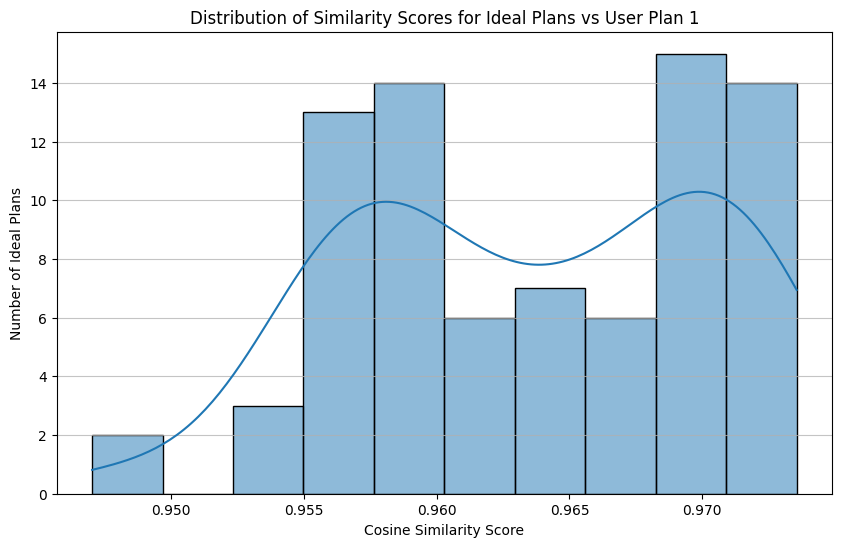


--- Processing User Plan 2 from /content/example2_compactness.csv ---
User-Drawn Plan (first 5 rows):


,district_x,comp_bc,comp_box_reock,comp_ch,comp_lw,comp_polsby,comp_reock,comp_schwartz,comp_skew,area_m2,perim_m,geometry_wkt,geometry,centroid_x,centroid_y,geo_area
0,1,0.758654,0.519932,0.671929,0.819298,0.180347,0.261107,0.424673,0.230388,2.125070e+10,1.244688e+07,"MULTIPOLYGON (((518857.8 2104318, 518791.3 210...","MULTIPOLYGON (((518857.8 2104318, 518791.3 210...",566904.672333,2.067670e+06,2.125070e+10
1,2,0.884087,0.567043,0.792333,0.984572,0.266901,0.368813,0.516625,0.408609,1.647505e+10,9.231670e+06,"MULTIPOLYGON (((383327.2 1936794, 383353.6 193...","MULTIPOLYGON (((383327.2 1936794, 383353.6 193...",479379.229646,2.029304e+06,1.647504e+10
2,3,0.922955,0.759116,0.903440,0.855712,0.347859,0.642717,0.589796,0.598419,2.606455e+10,1.441396e+07,"POLYGON ((431717.5 1831442, 431633.2 1831545, ...","POLYGON ((431717.5 1831442, 431633.2 1831545, ...",491127.618875,1.907701e+06,2.606455e+10
3,4,0.844182,0.868249,0.936913,0.453782,0.464330,0.405768,0.681418,0.377498,3.280773e+09,4.560965e+06,"POLYGON ((559786.9 2150517, 559764.8 2150908, ...","POLYGON ((559786.9 2150517, 559764.8 2150908, ...",600261.612687,2.170476e+06,3.280772e+09
4,5,0.844300,0.880113,0.965940,0.473075,0.506344,0.438989,0.711578,0.393420,3.266994e+09,2.612037e+06,"POLYGON ((646429 2164736, 646290.5 2164726, 64...","POLYGON ((646429 2164736, 646290.5 2164726, 64...",687793.360092,2.178322e+06,3.266999e+09



Calculating similarity for each ideal plan...

Comparing with Ideal Plan (Draw: 31454)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9712

Comparing with Ideal Plan (Draw: 31364)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9704

Comparing with Ideal Plan (Draw: 1940)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9574

Comparing with Ideal Plan (Draw: 31676)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9627

Comparing with Ideal Plan (Draw: 2381)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9577

Comparing with Ideal Plan (Draw: 32104)
  Using 7 metrics: ['comp_bc', 'comp_bo

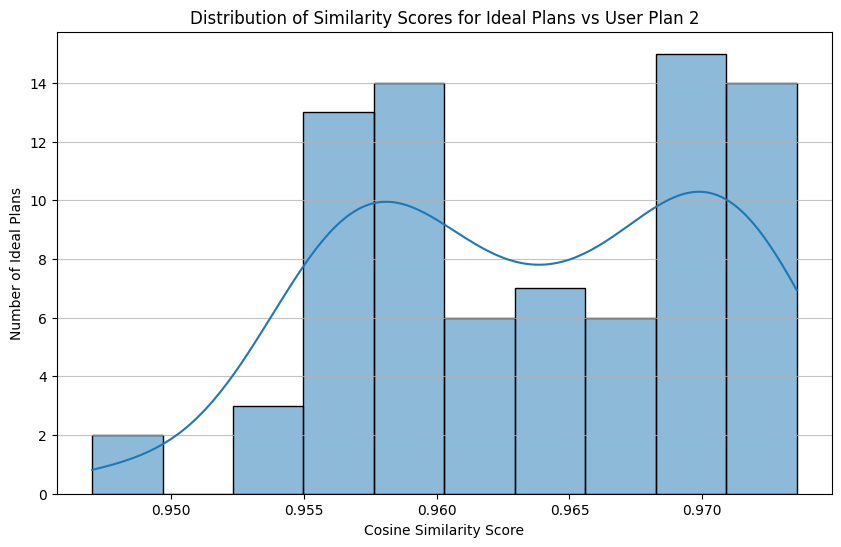


--- Processing User Plan 3 from /content/example3_compactness.csv ---
User-Drawn Plan (first 5 rows):


,district_x,comp_bc,comp_box_reock,comp_ch,comp_lw,comp_polsby,comp_reock,comp_schwartz,comp_skew,area_m2,perim_m,geometry_wkt,geometry,centroid_x,centroid_y,geo_area
0,1,0.829388,0.952890,0.993423,0.482389,0.643318,0.421696,0.802071,0.370219,3.543956e+09,3.223808e+06,"POLYGON ((645920.5 2154947, 645907.1 2154946, ...","POLYGON ((645920.5 2154947, 645907.1 2154946, ...",684376.527285,2.177479e+06,3.543961e+09
1,2,0.806371,0.814213,0.899353,0.498973,0.553178,0.429706,0.743760,0.443897,2.940284e+09,4.487841e+06,"POLYGON ((623404.4 2104580, 622997 2104543, 62...","POLYGON ((623404.4 2104580, 622997 2104543, 62...",619861.657727,2.151928e+06,2.940285e+09
2,3,0.920504,0.777217,0.900001,0.627803,0.575002,0.463472,0.758289,0.529142,1.366115e+10,9.610372e+06,"POLYGON ((481082.1 2079841, 481134.2 2079861, ...","POLYGON ((481082.1 2079841, 481134.2 2079861, ...",535229.505578,2.136415e+06,1.366116e+10
3,4,0.889514,0.675071,0.790409,0.655814,0.416529,0.427677,0.645390,0.411277,1.957429e+10,1.198068e+07,"POLYGON ((426800.3 1969945, 426796.4 1969944, ...","POLYGON ((426800.3 1969945, 426796.4 1969944, ...",511152.898496,2.030362e+06,1.957429e+10
4,5,0.776986,0.567175,0.778309,0.587259,0.342881,0.376860,0.585561,0.407283,2.697649e+10,1.582883e+07,"POLYGON ((421570.4 1837678, 421201.9 1838104, ...","POLYGON ((421570.4 1837678, 421201.9 1838104, ...",473071.477148,1.862804e+06,2.697650e+10



Calculating similarity for each ideal plan...

Comparing with Ideal Plan (Draw: 31454)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9661

Comparing with Ideal Plan (Draw: 31364)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9657

Comparing with Ideal Plan (Draw: 1940)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9659

Comparing with Ideal Plan (Draw: 31676)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9577

Comparing with Ideal Plan (Draw: 2381)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9713

Comparing with Ideal Plan (Draw: 32104)
  Using 7 metrics: ['comp_bc', 'comp_bo

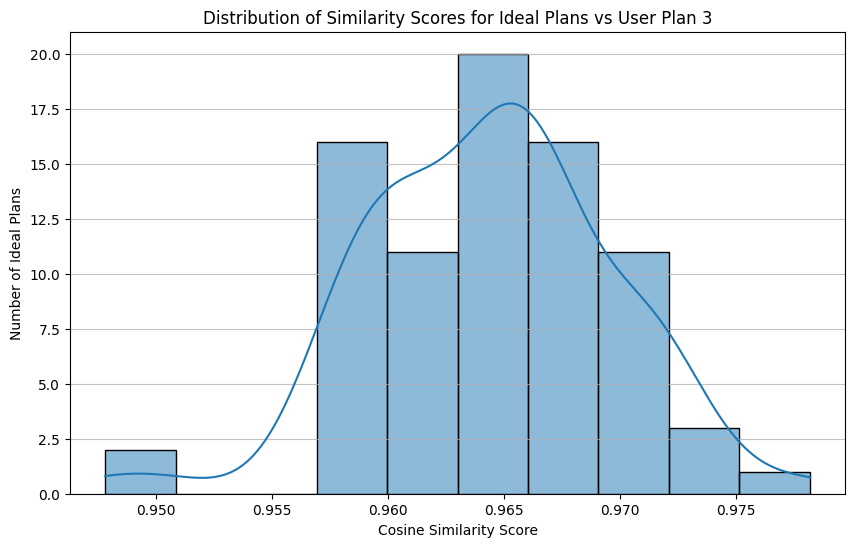


--- Processing User Plan 4 from /content/example4_compactness.csv ---
User-Drawn Plan (first 5 rows):


,district_x,comp_bc,comp_box_reock,comp_ch,comp_lw,comp_polsby,comp_reock,comp_schwartz,comp_skew,area_m2,perim_m,geometry_wkt,geometry,centroid_x,centroid_y,geo_area
0,1,0.894944,0.751528,0.931963,0.746269,0.626053,0.568136,0.791235,0.569344,4.143504e+09,1.410811e+06,"POLYGON ((682655.2 2119210, 682650 2119210, 68...","POLYGON ((682655.2 2119210, 682650 2119210, 68...",702726.434379,2.161241e+06,4.143511e+09
1,2,0.937000,0.825493,0.914409,0.878299,0.606101,0.578079,0.778525,0.597565,2.604927e+08,1.757341e+06,"POLYGON ((684606.4 2104656, 684600 2104695, 68...","POLYGON ((684606.4 2104656, 684600 2104695, 68...",691177.169505,2.110916e+06,2.604925e+08
2,3,0.902526,0.685109,0.846997,0.769428,0.516114,0.563848,0.718410,0.554519,1.126087e+08,1.062138e+06,"POLYGON ((679199.8 2130837, 679166.1 2130839, ...","POLYGON ((679199.8 2130837, 679166.1 2130839, ...",682119.634969,2.137808e+06,1.126080e+08
3,4,0.927207,0.716478,0.874275,0.988564,0.526755,0.689929,0.725779,0.630470,4.295688e+08,2.124625e+06,"POLYGON ((662178.3 2138273, 662170.8 2138272, ...","POLYGON ((662178.3 2138273, 662170.8 2138272, ...",670921.676739,2.145671e+06,4.295690e+08
4,5,0.951662,0.736017,0.900908,0.912314,0.548887,0.599860,0.740869,0.633506,2.551658e+08,1.616273e+06,"POLYGON ((666839.9 2118055, 666823.1 2118054, ...","POLYGON ((666839.9 2118055, 666823.1 2118054, ...",672335.743519,2.125613e+06,2.551665e+08



Calculating similarity for each ideal plan...

Comparing with Ideal Plan (Draw: 31454)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9727

Comparing with Ideal Plan (Draw: 31364)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9784

Comparing with Ideal Plan (Draw: 1940)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9691

Comparing with Ideal Plan (Draw: 31676)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9770

Comparing with Ideal Plan (Draw: 2381)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9763

Comparing with Ideal Plan (Draw: 32104)
  Using 7 metrics: ['comp_bc', 'comp_bo

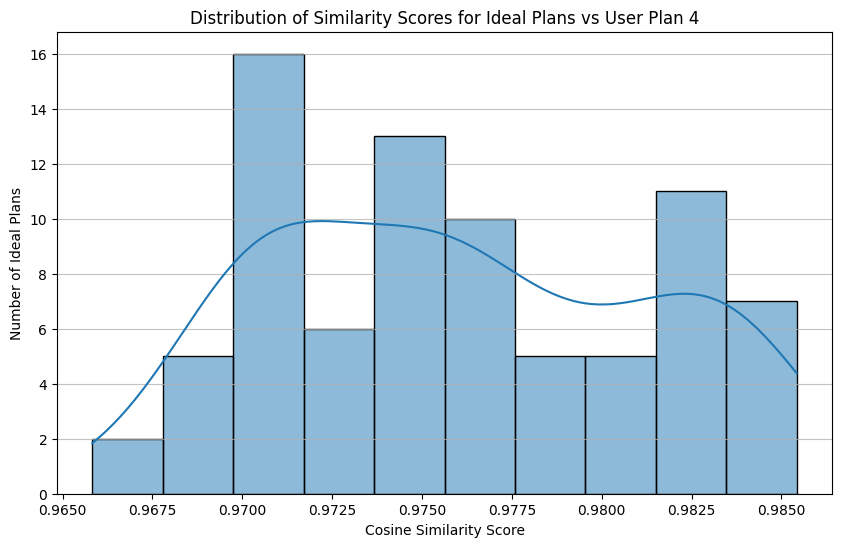


--- Processing User Plan 5 from /content/example5_compactness.csv ---
User-Drawn Plan (first 5 rows):


,district_x,comp_bc,comp_box_reock,comp_ch,comp_lw,comp_polsby,comp_reock,comp_schwartz,comp_skew,area_m2,perim_m,geometry_wkt,geometry,centroid_x,centroid_y,geo_area
0,1,0.747851,0.537368,0.678212,0.919778,0.151750,0.251151,0.389551,0.196566,6.016545e+08,2.493465e+06,"POLYGON ((650275.7 2111670, 650275.4 2111666, ...","POLYGON ((650275.7 2111670, 650275.4 2111666, ...",660060.293140,2.134257e+06,6.016536e+08
1,2,0.930517,0.582285,0.738429,0.626103,0.265065,0.327754,0.514845,0.435406,2.028243e+09,1.904338e+06,"POLYGON ((656033 2114289, 656027.5 2114288, 65...","POLYGON ((656033 2114289, 656027.5 2114288, 65...",700962.423140,2.138603e+06,2.028244e+09
2,3,0.724369,0.223865,0.308919,0.770464,0.046086,0.163994,0.214677,0.122587,3.994548e+08,1.824940e+06,"POLYGON ((642898.9 2107370, 642898.5 2107376, ...","POLYGON ((642898.9 2107370, 642898.5 2107376, ...",654197.974940,2.123989e+06,3.994550e+08
3,4,0.753471,0.162725,0.210426,0.951862,0.023744,0.126635,0.154092,0.073411,4.016615e+08,1.906289e+06,"MULTIPOLYGON (((644649.6 2105701, 644651.8 210...","MULTIPOLYGON (((644649.6 2105701, 644651.8 210...",656416.023357,2.132504e+06,4.016603e+08
4,5,0.711833,0.139568,0.172945,0.988361,0.023376,0.112556,0.152893,0.069093,3.917245e+08,1.820822e+06,"MULTIPOLYGON (((639605.9 2104503, 639605.6 210...","MULTIPOLYGON (((639605.9 2104503, 639605.6 210...",655344.794080,2.129366e+06,3.917227e+08



Calculating similarity for each ideal plan...

Comparing with Ideal Plan (Draw: 31454)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9137

Comparing with Ideal Plan (Draw: 31364)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9219

Comparing with Ideal Plan (Draw: 1940)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9108

Comparing with Ideal Plan (Draw: 31676)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9152

Comparing with Ideal Plan (Draw: 2381)
  Using 7 metrics: ['comp_bc', 'comp_box_reock', 'comp_ch', 'comp_lw', 'comp_reock', 'comp_schwartz', 'comp_skew']
Similarity: 0.9264

Comparing with Ideal Plan (Draw: 32104)
  Using 7 metrics: ['comp_bc', 'comp_bo

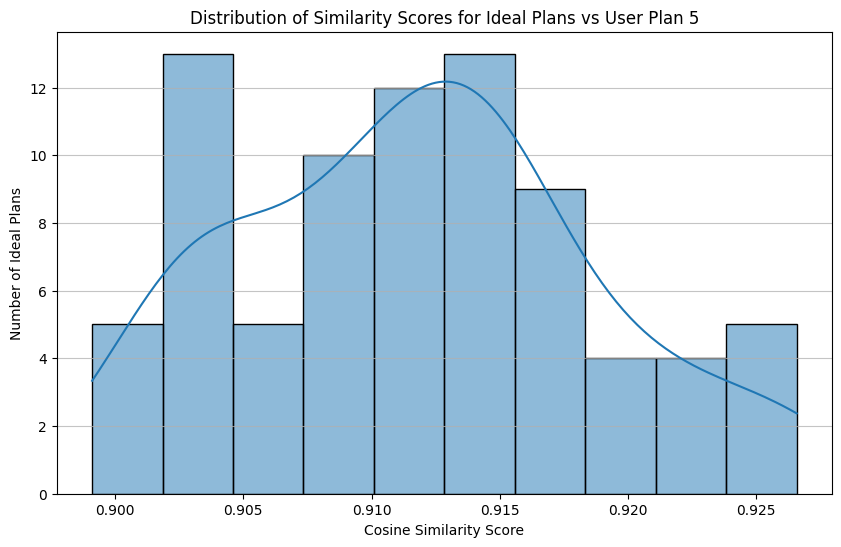

In [ ]:
user_plans = ['/content/example2_compactness.csv','/content/example2_compactness.csv','/content/example3_compactness.csv', '/content/example4_compactness.csv', '/content/example5_compactness.csv']

for i, plan_file in enumerate(user_plans):
  print(f"\n--- Processing User Plan {i+1} from {plan_file} ---")
  user_plan = pd.read_csv(plan_file)

  # Convert geometry WKT to shapely geometry objects and create GeoDataFrames
  user_plan['geometry'] = user_plan['geometry_wkt'].apply(wkt.loads)
  user_plan_gdf = gpd.GeoDataFrame(user_plan, geometry='geometry')

  # Calculate geographic features for user_plan_gdf: centroids and area
  user_plan_gdf['centroid_x'] = user_plan_gdf.geometry.centroid.x
  user_plan_gdf['centroid_y'] = user_plan_gdf.geometry.centroid.y
  user_plan_gdf['geo_area'] = user_plan_gdf.geometry.area # Calculate area from geometry directly

  # Rename 'district' in user_plan_gdf to 'district_x' to match 'make_vector' function's expectation
  user_plan_gdf.rename(columns={'district': 'district_x'}, inplace=True)

  print("User-Drawn Plan (first 5 rows):")
  display(user_plan_gdf.head())

  # Ensure 'Plan' and 'draw' are string types for consistent merging
  merged_ideal['Plan'] = merged_ideal['Plan'].astype(str)
  stats['draw'] = stats['draw'].astype(str)

  # Correctly merge merged_ideal and stats on 'Plan'/'draw' AND 'district'
  # This creates an intermediate DataFrame where each row correctly corresponds to a unique
  # district within a specific plan, preventing the cross-product issue.
  intermediate_ideal_stats = pd.merge(
      merged_ideal, # Has 'district' and 'Plan'
      stats,        # Has 'district' and 'draw'
      left_on=['Plan', 'district'],
      right_on=['draw', 'district'],
      how='left',
      suffixes=('_merged_ideal', '_stats')
  )

  # The resulting dataframe 'intermediate_ideal_stats' will have a 'district' column (the common one).
  # Rename 'district' to 'district_x' to match 'make_vector' function's expectation.
  intermediate_ideal_stats.rename(columns={'district': 'district_x'}, inplace=True)
  # Rename the plan identifier column from stats to 'draw'
  intermediate_ideal_stats.rename(columns={'draw_stats': 'draw'}, inplace=True)

  # Now merge this correctly structured intermediate_ideal_stats with the geographic data (districts)
  final_ideal_plans_gdf = intermediate_ideal_stats.merge(districts,
                                                left_on='district_x', # Merge on the now consistent 'district_x'
                                                right_on='cd_2020',
                                                how='inner',
                                                suffixes=('_ideal_metrics', '_map_geom'))

  # Convert to GeoDataFrame after merge to enable geographic operations
  final_ideal_plans_gdf = gpd.GeoDataFrame(final_ideal_plans_gdf, geometry='geometry')

  # Ensure geometric features are calculated for the ideal plans
  final_ideal_plans_gdf['centroid_x'] = final_ideal_plans_gdf.geometry.centroid.x
  final_ideal_plans_gdf['centroid_y'] = final_ideal_plans_gdf.geometry.centroid.y
  final_ideal_plans_gdf['geo_area'] = final_ideal_plans_gdf.geometry.area

  print("\nCalculating similarity for each ideal plan...")

  similarity_results = []
  # Filter out NaN values from 'draw' column before getting unique draws
  unique_draws = final_ideal_plans_gdf['draw'].dropna().unique()

  for draw_id in unique_draws:
      # Extract data for a single ideal plan (should now have 17 rows)
      single_ideal_plan_gdf = final_ideal_plans_gdf[final_ideal_plans_gdf['draw'] == draw_id].copy()

      print(f"\nComparing with Ideal Plan (Draw: {draw_id})")
      similarity_score = calculate_similarity(single_ideal_plan_gdf, user_plan_gdf, f"Ideal Plan {draw_id}", "User-Drawn Plan")

      if similarity_score is not None:
          similarity_results.append({'draw': draw_id, 'similarity': similarity_score})

  # Rank the results
  if similarity_results:
      ranked_results = pd.DataFrame(similarity_results).sort_values(by='similarity', ascending=False)
      print(f"\n--- Ranked Ideal Plans by Similarity to User-Drawn Plan ({plan_file}) ---")
      print(ranked_results.head())

      # Plotting the distribution of similarity scores
      plt.figure(figsize=(10, 6))
      sns.histplot(ranked_results['similarity'], kde=True, bins=10)
      plt.title(f'Distribution of Similarity Scores for Ideal Plans vs User Plan {i+1}')
      plt.xlabel('Cosine Similarity Score')
      plt.ylabel('Number of Ideal Plans')
      plt.grid(axis='y', alpha=0.75)
      plt.show()
  else:
      print("No similarity results to display.")